# Experiment Analysis

In [194]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

pd.set_option('display.max_columns',None)
exp_name = 'e_100K'
#exp_name = 'e_1M'
#version='historic_results/100_trials/'
version=''

In [195]:
df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)

In [196]:
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,ds_users,ds_items,ds_time
1,e_100K_1c1dcs,0.230051,0.099403,0.049744,0.087206,0.244111,0.097977,0.051605,0.088138,3509.143770,22.440837,0.088540,602,7740,53072,8176,8177,1,128,0.000232,0.000014,639,RMSprop,"[0.6872614026069641, 0.6639332175254822, 0.599...","[0.6570164561271667, 0.6411582231521606, 0.594...",320.0,227.0,15.584469
2,e_100K_1c1dcs_rand1,0.311422,0.095271,0.048211,0.087957,0.305281,0.099297,0.047889,0.089193,3740.022985,20.185381,0.087992,609,7162,53072,8176,8177,1,32,0.000135,0.000206,1541,RMSprop,"[0.6921934485435486, 0.6881556510925293, 0.681...","[0.6842504143714905, 0.6821179389953613, 0.676...",NaN,NaN,NaN
3,e_100K_1c1dcs_rand2,0.212110,0.118122,0.055196,0.093903,0.208589,0.127804,0.053547,0.101291,3450.898518,26.274353,0.092062,609,7173,53072,8176,8177,1,256,0.000153,0.000009,981,RMSprop,"[0.6795362234115601, 0.6596691012382507, 0.620...","[0.6221908926963806, 0.6113561987876892, 0.582...",NaN,NaN,NaN
4,e_100K_1c1dcs_rand3,0.243106,0.079926,0.037819,0.063539,0.256601,0.083671,0.042568,0.069494,3857.211518,28.697948,0.088982,609,7165,53072,8176,8177,1,256,0.004460,0.001586,3826,RMSprop,"[0.691761314868927, 0.10544346272945404, 0.094...","[0.6192430257797241, 0.244714617729187, 0.2460...",NaN,NaN,NaN
5,e_100K_1c1dcs_rand4,0.289047,0.112246,0.051107,0.089518,0.296956,0.114180,0.053970,0.094270,3354.874830,22.400790,0.088847,609,7199,53072,8176,8177,1,96,0.000083,0.000036,2324,Adam,"[0.6881999969482422, 0.6846320033073425, 0.680...","[0.6661165356636047, 0.6649761199951172, 0.661...",NaN,NaN,NaN


## Trial analysis

In [197]:
experiments_ran = df[~df['experiment'].str.contains('_rand')]['experiment']

data =  {}
trials = {}
ranges = ''

for exp in experiments_ran:
    study = optuna.load_study(study_name=f'Study_{exp}', storage=f'sqlite:///{version}{exp_name}.sqlite3')
    plot_param_importances(study)

    importance = get_param_importances(study)
    params = {}
    for param, value in importance.items():
        #print(f"{param}: {value}")
        params[param] = value

    ranges = study.get_trials()[0].distributions

    pruned_trials = len(study.get_trials(deepcopy=False, states=[TrialState.PRUNED]))
    complete_trials = len(study.get_trials(deepcopy=False, states=[TrialState.COMPLETE]))

    data[exp] = params
    trials[exp] = {'pruned':pruned_trials, 'complete':complete_trials}

importances_df = pd.DataFrame.from_dict(data, orient='index')
trials_df = pd.DataFrame.from_dict(trials, orient='index')
importances_df

,n_layers,batch_size,embedding_dim,optimizer,lambda_val,lr
e_100K_1c1dcs,0.617752,0.239361,0.093892,0.025243,0.013205,0.010548
e_100K_1c2dcs,0.172914,0.139307,0.326316,0.064996,0.086193,0.210273
e_100K_1c3dcs,0.585991,0.036517,0.304669,0.061318,0.007147,0.004358
e_100K_full,0.578084,0.049412,0.301427,0.028281,0.033787,0.009009


In [198]:
ranges

{'n_layers': IntDistribution(high=4, log=False, low=1, step=1),
 'embedding_dim': CategoricalDistribution(choices=(32, 64, 96, 128, 256)),
 'lr': FloatDistribution(high=0.1, log=True, low=1e-05, step=None),
 'lambda_val': FloatDistribution(high=0.1, log=True, low=1e-06, step=None),
 'batch_size': IntDistribution(high=4096, log=False, low=512, step=1),
 'optimizer': CategoricalDistribution(choices=('Adam', 'RMSprop', 'SGD'))}


|Hyperparameter|Type|Range (Alan)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

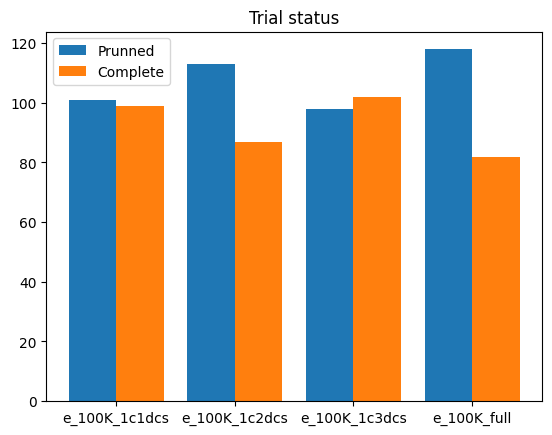

In [199]:
x = np.arange(len(trials_df))
width = 0.4

plt.bar(x = x, width = width, height=trials_df['pruned'], label='Prunned')
plt.bar(x = x+width, width = width, height=trials_df['complete'], label='Complete')

plt.legend()
plt.xticks(x+width/2, trials_df.index)

plt.title('Trial status')

plt.show()

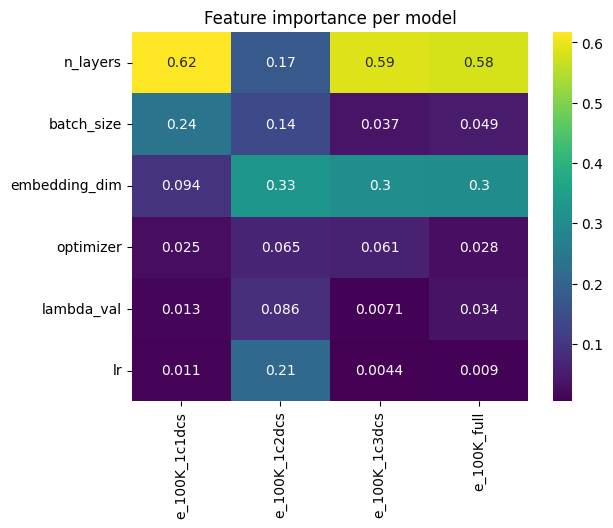

In [200]:
sns.heatmap(importances_df.T, annot=True, cmap='viridis')
plt.title('Feature importance per model')
plt.show()

## Visualizations

In [201]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
time_features = ['optim_time','train_time','infer_time','ds_time']
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
random_experiments_stats

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
1,1c1dcs,0.230051,0.099403,0.049744,0.087206,0.244111,0.097977,0.051605,0.088138,3509.143770,22.440837,0.088540,15.584469,53072,320.0,227.0,1,128,0.000232,0.000014,639,RMSprop
2,1c1dcs_rand,0.311422,0.095271,0.048211,0.087957,0.305281,0.099297,0.047889,0.089193,3740.022985,20.185381,0.087992,NaN,53072,NaN,NaN,1,32,0.000135,0.000206,1541,RMSprop
3,1c1dcs_rand,0.212110,0.118122,0.055196,0.093903,0.208589,0.127804,0.053547,0.101291,3450.898518,26.274353,0.092062,NaN,53072,NaN,NaN,1,256,0.000153,0.000009,981,RMSprop
4,1c1dcs_rand,0.243106,0.079926,0.037819,0.063539,0.256601,0.083671,0.042568,0.069494,3857.211518,28.697948,0.088982,NaN,53072,NaN,NaN,1,256,0.004460,0.001586,3826,RMSprop
5,1c1dcs_rand,0.289047,0.112246,0.051107,0.089518,0.296956,0.114180,0.053970,0.094270,3354.874830,22.400790,0.088847,NaN,53072,NaN,NaN,1,96,0.000083,0.000036,2324,Adam
6,1c1dcs_rand,0.217678,0.098347,0.042249,0.072932,0.207616,0.112903,0.049155,0.088024,3496.384202,27.203124,0.089226,NaN,53072,NaN,NaN,1,256,0.000094,0.000006,3398,RMSprop
7,1c2dcs,0.180828,0.087480,0.040630,0.074450,0.186163,0.102906,0.046030,0.087998,3370.973211,27.866584,0.087745,18.650446,54402,325.0,3332.0,1,256,0.000253,0.000079,1415,Adam
8,1c2dcs_rand,0.202457,0.128204,0.053152,0.093582,0.209473,0.137093,0.057348,0.105742,4144.946941,27.173705,0.091567,NaN,54402,NaN,NaN,1,256,0.000214,0.000008,585,Adam
9,1c2dcs_rand,0.235621,0.075918,0.036116,0.060823,0.255917,0.094701,0.042990,0.072658,5765.200845,28.524006,0.089013,NaN,54402,NaN,NaN,1,256,0.017938,0.001124,3783,RMSprop
10,1c2dcs_rand,0.223656,0.136469,0.059796,0.102296,0.219167,0.148960,0.060980,0.110989,4099.585150,26.435075,0.092196,NaN,54402,NaN,NaN,1,256,0.000159,0.000001,649,RMSprop


In [202]:
total_run = random_experiments_stats[time_features].sum().sum()
print('Total run time: ', str(datetime.timedelta(seconds=total_run)))

Total run time:  20:44:16.945505


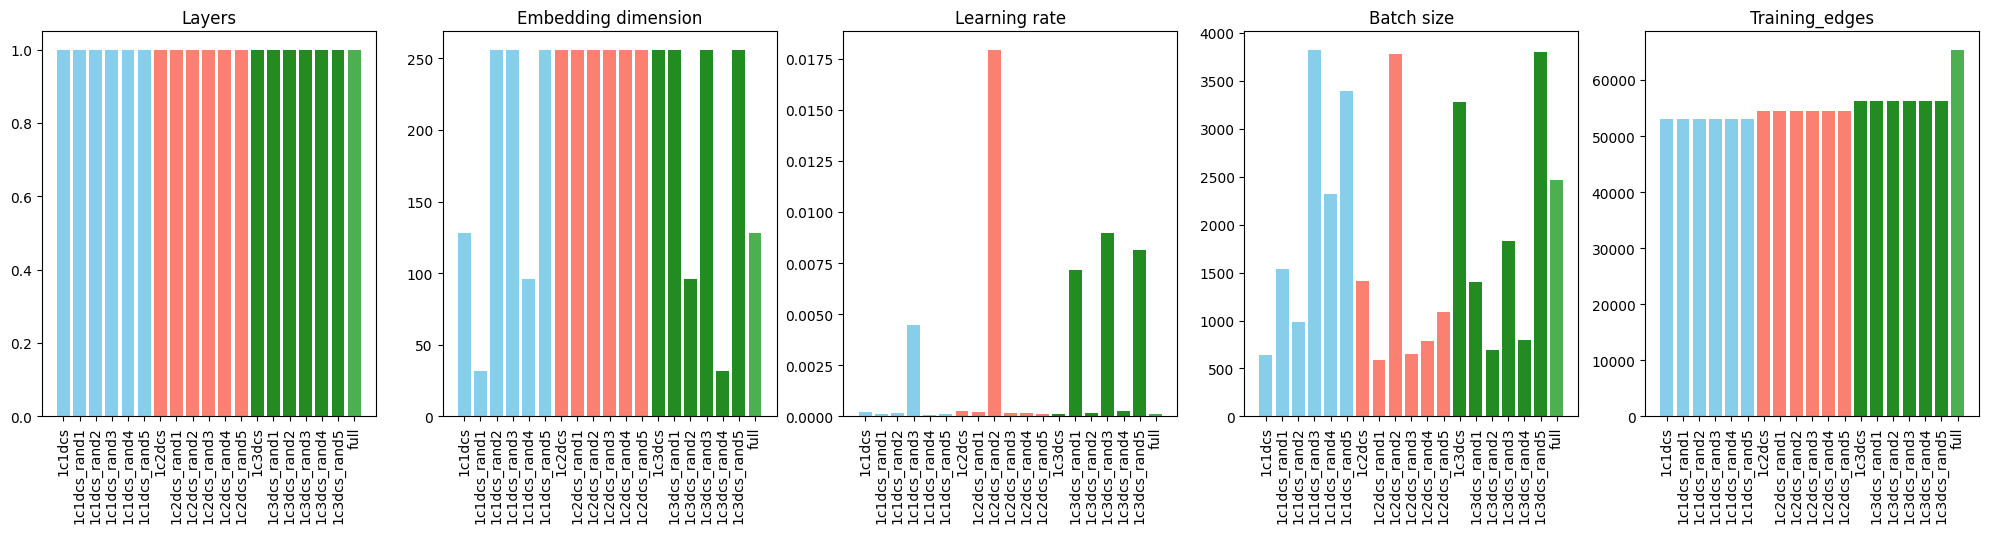

In [203]:
colors={'full':'#4CAF50', '1c1dcs':'skyblue','1c2dcs':'salmon','1c3dcs':'forestgreen'}

def set_color(text):
    for col in colors.keys():
        if col in text:
            return(colors[col])
            

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])
new_df['color'] = new_df['experiment'].apply(set_color)


plots=['n_layers','embedding_dim','lr','batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Batch size','Training_edges']


plt.figure(figsize=(25,5))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(new_df['experiment'], new_df[metric] , color=new_df['color'], capsize=5)
    plt.title(titles[i])
    plt.xticks(rotation=90)

plt.show()


In [204]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.230051,0.000000,0.099403,0.000000,0.049744,0.000000,0.087206,0.000000,0.244111,0.000000,0.097977,0.000000,0.051605,0.000000,0.088138,0.000000,3509.143770,0.000000,22.440837,0.000000,0.088540,0.000000,15.584469,0.0,53072.0,320.0,227.0,[1],[128],[0.00023242230831577263],[1.447176289706694e-05],[639],[RMSprop]
1,1c1dcs_rand,0.254672,0.043921,0.100782,0.015028,0.046917,0.006934,0.081570,0.012805,0.255009,0.046611,0.107571,0.016742,0.049426,0.004666,0.088454,0.011820,3579.878411,210.234181,24.952319,3.538278,0.089422,0.001547,0.000000,0.0,53072.0,0.0,0.0,[1],"[32, 256, 96]","[0.00013467055761828147, 0.0001533128516250610...","[0.00020635794913070017, 8.633810969112886e-06...","[1541, 981, 3826, 2324, 3398]","[RMSprop, Adam]"
2,1c2dcs,0.180828,0.000000,0.087480,0.000000,0.040630,0.000000,0.074450,0.000000,0.186163,0.000000,0.102906,0.000000,0.046030,0.000000,0.087998,0.000000,3370.973211,0.000000,27.866584,0.000000,0.087745,0.000000,18.650446,0.0,54402.0,325.0,3332.0,[1],[256],[0.00025296016056648826],[7.882655090752635e-05],[1415],[Adam]
3,1c2dcs_rand,0.217948,0.015547,0.115099,0.023789,0.050068,0.008858,0.086918,0.015822,0.222832,0.020263,0.127527,0.021422,0.054071,0.006966,0.095607,0.015336,4409.906646,770.794365,27.262202,0.765726,0.090821,0.001258,0.000000,0.0,54402.0,0.0,0.0,[1],[256],"[0.00021391840724612382, 0.01793799285108155, ...","[8.189335383473967e-06, 0.0011242930299209639,...","[585, 3783, 649, 791, 1087]","[Adam, RMSprop]"
4,1c3dcs,0.218643,0.000000,0.080682,0.000000,0.043271,0.000000,0.064709,0.000000,0.222872,0.000000,0.093739,0.000000,0.047635,0.000000,0.082279,0.000000,4451.076792,0.000000,29.922509,0.000000,0.088576,0.000000,19.934451,0.0,56335.0,343.0,4540.0,[1],[256],[0.0001269856236490417],[0.00045328812725947606],[3280],[Adam]
5,1c3dcs_rand,0.245592,0.015264,0.099777,0.021019,0.046218,0.009041,0.078224,0.016203,0.248231,0.016696,0.103814,0.019910,0.048530,0.008876,0.082680,0.017616,3926.071214,876.647249,24.856569,4.074506,0.088810,0.001129,0.000000,0.0,56335.0,0.0,0.0,[1],"[256, 96, 32]","[0.0071468999357604205, 0.00017132800977832704...","[0.001064593853557518, 1.907689964735128e-06, ...","[1401, 697, 1834, 797, 3805]","[RMSprop, Adam]"
6,full,0.257596,0.000000,0.107568,0.000000,0.055877,0.000000,0.093619,0.000000,0.250997,0.000000,0.123292,0.000000,0.061064,0.000000,0.103301,0.000000,3203.432820,0.000000,21.582898,0.000000,0.089793,0.000000,0.000000,0.0,65410.0,0.0,0.0,[1],[128],[0.00010676426690590239],[3.350825674522868e-05],[2469],[RMSprop]


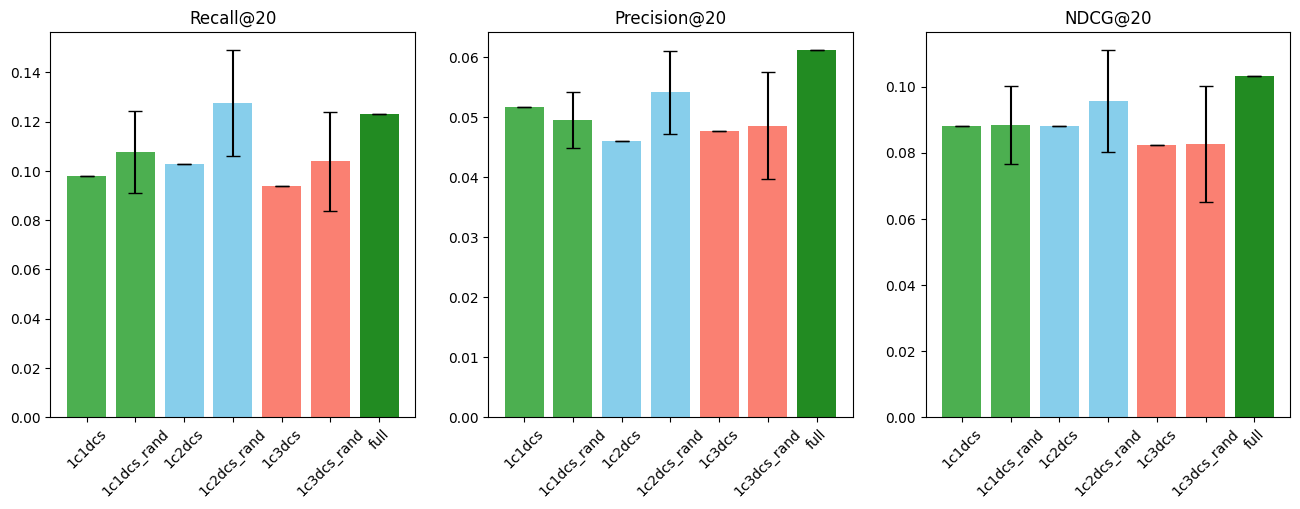

In [205]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']
plt.figure(figsize=(16,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(result['experiment'], result[metric+'_mean'], yerr=result[metric+'_std'], color=colors, capsize=5)
    plt.title(titles[i])
    plt.xticks(rotation=45)

plt.show()

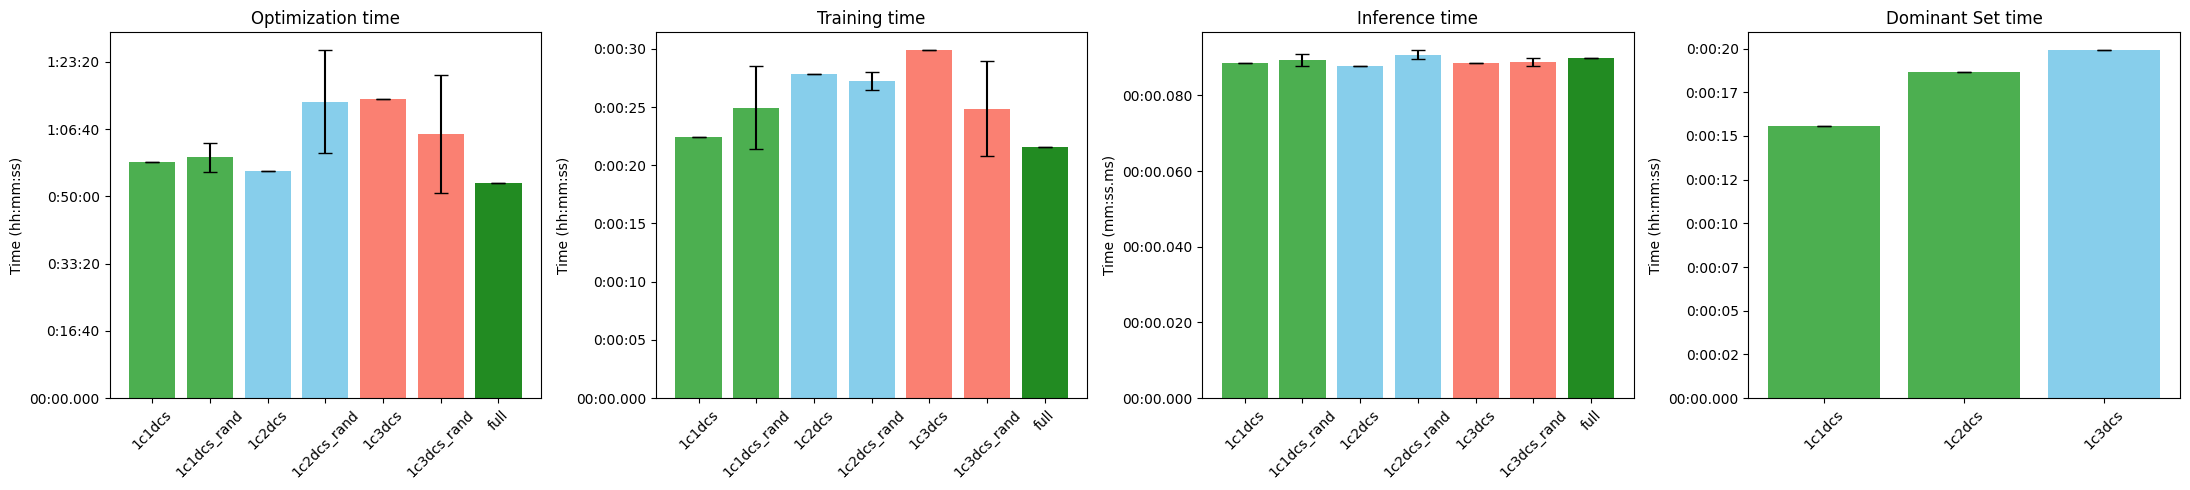

In [206]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta

plots=['optim_time','train_time','infer_time','ds_time']
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']
plt.figure(figsize=(22,5))

def format_time(x, pos):
    if x>=1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    values = result[metric+'_mean']>0
    x=result['experiment'][values]
    y=result[metric+'_mean'][values]
    yerr=result[metric+'_std'][values]

    #plt.bar(result['experiment'], result[metric+'_mean'], yerr=result[metric+'_std'], color=colors, capsize=5)
    plt.bar(x, y, yerr=yerr, color=colors, capsize=5)
    plt.title(titles[i])
    
    if result[metric+'_mean'].mean() < 1:
        plt.ylabel('Time (mm:ss.ms)')
    else:
        plt.ylabel('Time (hh:mm:ss)')
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [207]:
metric = 'ds_time'
values = result[metric+'_mean']>0
result[metric+'_mean'][values]

colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']
values 

0     True
1    False
2     True
3    False
4     True
5    False
6    False
Name: ds_time_mean, dtype: bool

In [208]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


In [209]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,train_edges_mean,ds_users_mean,ds_items_mean,optim_time,train_time,infer_time,ds_time,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.2301,0.0994,0.0497,0.0872,0.2441,0.0980,0.0516,0.0881,53072.0,320.0,227.0,00:58:29,00:00:22,00:00:00,00:00:15,[1],[128],[0.00023242230831577263],[1.447176289706694e-05],[639],[RMSprop]
1,1c1dcs_rand,0.2547 ± 0.0439,0.1008 ± 0.0150,0.0469 ± 0.0069,0.0816 ± 0.0128,0.2550 ± 0.0466,0.1076 ± 0.0167,0.0494 ± 0.0047,0.0885 ± 0.0118,53072.0,0.0,0.0,00:59:39 ± 00:03:30,00:00:24 ± 00:00:03,00:00:00 ± 00:00:00,00:00:00,[1],"[32, 256, 96]","[0.00013467055761828147, 0.0001533128516250610...","[0.00020635794913070017, 8.633810969112886e-06...","[1541, 981, 3826, 2324, 3398]","[RMSprop, Adam]"
2,1c2dcs,0.1808,0.0875,0.0406,0.0745,0.1862,0.1029,0.0460,0.0880,54402.0,325.0,3332.0,00:56:10,00:00:27,00:00:00,00:00:18,[1],[256],[0.00025296016056648826],[7.882655090752635e-05],[1415],[Adam]
3,1c2dcs_rand,0.2179 ± 0.0155,0.1151 ± 0.0238,0.0501 ± 0.0089,0.0869 ± 0.0158,0.2228 ± 0.0203,0.1275 ± 0.0214,0.0541 ± 0.0070,0.0956 ± 0.0153,54402.0,0.0,0.0,01:13:29 ± 00:12:50,00:00:27 ± 00:00:00,00:00:00 ± 00:00:00,00:00:00,[1],[256],"[0.00021391840724612382, 0.01793799285108155, ...","[8.189335383473967e-06, 0.0011242930299209639,...","[585, 3783, 649, 791, 1087]","[Adam, RMSprop]"
4,1c3dcs,0.2186,0.0807,0.0433,0.0647,0.2229,0.0937,0.0476,0.0823,56335.0,343.0,4540.0,01:14:11,00:00:29,00:00:00,00:00:19,[1],[256],[0.0001269856236490417],[0.00045328812725947606],[3280],[Adam]
5,1c3dcs_rand,0.2456 ± 0.0153,0.0998 ± 0.0210,0.0462 ± 0.0090,0.0782 ± 0.0162,0.2482 ± 0.0167,0.1038 ± 0.0199,0.0485 ± 0.0089,0.0827 ± 0.0176,56335.0,0.0,0.0,01:05:26 ± 00:14:36,00:00:24 ± 00:00:04,00:00:00 ± 00:00:00,00:00:00,[1],"[256, 96, 32]","[0.0071468999357604205, 0.00017132800977832704...","[0.001064593853557518, 1.907689964735128e-06, ...","[1401, 697, 1834, 797, 3805]","[RMSprop, Adam]"
6,full,0.2576,0.1076,0.0559,0.0936,0.2510,0.1233,0.0611,0.1033,65410.0,0.0,0.0,00:53:23,00:00:21,00:00:00,00:00:00,[1],[128],[0.00010676426690590239],[3.350825674522868e-05],[2469],[RMSprop]


In [210]:
cols = result_viewable.columns

for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in cols }
    result_viewable.rename(rename_dict, axis=1, inplace=True)

result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.2301,0.0994,0.0497,0.0872,0.2441,0.0980,0.0516,0.0881,53072.0,320.0,227.0,00:58:29,00:00:22,00:00:00,00:00:15,[1],[128],[0.00023242230831577263],[1.447176289706694e-05],[639],[RMSprop]
1,1c1dcs_rand,0.2547 ± 0.0439,0.1008 ± 0.0150,0.0469 ± 0.0069,0.0816 ± 0.0128,0.2550 ± 0.0466,0.1076 ± 0.0167,0.0494 ± 0.0047,0.0885 ± 0.0118,53072.0,0.0,0.0,00:59:39 ± 00:03:30,00:00:24 ± 00:00:03,00:00:00 ± 00:00:00,00:00:00,[1],"[32, 256, 96]","[0.00013467055761828147, 0.0001533128516250610...","[0.00020635794913070017, 8.633810969112886e-06...","[1541, 981, 3826, 2324, 3398]","[RMSprop, Adam]"
2,1c2dcs,0.1808,0.0875,0.0406,0.0745,0.1862,0.1029,0.0460,0.0880,54402.0,325.0,3332.0,00:56:10,00:00:27,00:00:00,00:00:18,[1],[256],[0.00025296016056648826],[7.882655090752635e-05],[1415],[Adam]
3,1c2dcs_rand,0.2179 ± 0.0155,0.1151 ± 0.0238,0.0501 ± 0.0089,0.0869 ± 0.0158,0.2228 ± 0.0203,0.1275 ± 0.0214,0.0541 ± 0.0070,0.0956 ± 0.0153,54402.0,0.0,0.0,01:13:29 ± 00:12:50,00:00:27 ± 00:00:00,00:00:00 ± 00:00:00,00:00:00,[1],[256],"[0.00021391840724612382, 0.01793799285108155, ...","[8.189335383473967e-06, 0.0011242930299209639,...","[585, 3783, 649, 791, 1087]","[Adam, RMSprop]"
4,1c3dcs,0.2186,0.0807,0.0433,0.0647,0.2229,0.0937,0.0476,0.0823,56335.0,343.0,4540.0,01:14:11,00:00:29,00:00:00,00:00:19,[1],[256],[0.0001269856236490417],[0.00045328812725947606],[3280],[Adam]
5,1c3dcs_rand,0.2456 ± 0.0153,0.0998 ± 0.0210,0.0462 ± 0.0090,0.0782 ± 0.0162,0.2482 ± 0.0167,0.1038 ± 0.0199,0.0485 ± 0.0089,0.0827 ± 0.0176,56335.0,0.0,0.0,01:05:26 ± 00:14:36,00:00:24 ± 00:00:04,00:00:00 ± 00:00:00,00:00:00,[1],"[256, 96, 32]","[0.0071468999357604205, 0.00017132800977832704...","[0.001064593853557518, 1.907689964735128e-06, ...","[1401, 697, 1834, 797, 3805]","[RMSprop, Adam]"
6,full,0.2576,0.1076,0.0559,0.0936,0.2510,0.1233,0.0611,0.1033,65410.0,0.0,0.0,00:53:23,00:00:21,00:00:00,00:00:00,[1],[128],[0.00010676426690590239],[3.350825674522868e-05],[2469],[RMSprop]


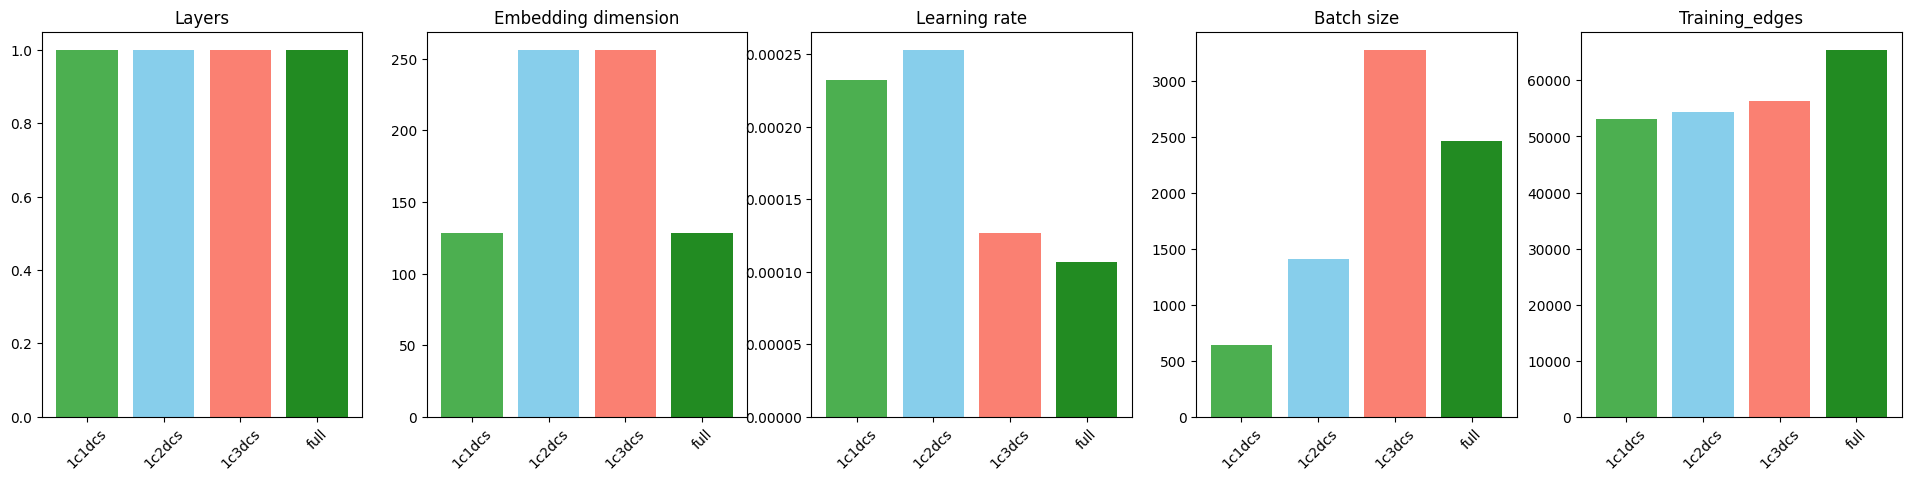

In [211]:
plots=['n_layers','embedding_dim','lr','batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Batch size','Training_edges']
colors=[ '#4CAF50','skyblue','salmon','forestgreen']
plt.figure(figsize=(24,5))

cols = ['n_layers','embedding_dim','lr','batch_size']

config_values = result_viewable[~result_viewable['experiment'].str.contains('_rand')][['experiment']+plots]

for col in cols:
    config_values[col] = config_values[col].apply(lambda x: x[0])

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)

    plt.bar(config_values['experiment'], config_values[metric], color=colors, capsize=5)
    plt.title(titles[i])
    plt.xticks(rotation=45)

plt.show()
